# Exploratiry Data Analysis

In [1]:
# Import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [3]:
# Load the dataset

listings=pd.read_csv("../data/clean/listings_clean.csv")

/var/folders/kx/374_58594qvbkr4ww4fyrns00000gn/T/ipykernel_31350/847863679.py:3: DtypeWarning: Columns (19,22,23) have mixed types. Specify dtype option on import or set low_memory=False.
  listings=pd.read_csv("../data/clean/listings_clean.csv")


In [6]:
listings.shape
listings.head

<bound method NDFrame.head of                         id                                       listing_url  \
0                     2539                 https://www.airbnb.com/rooms/2539   
1                     6848                 https://www.airbnb.com/rooms/6848   
2                     6872                 https://www.airbnb.com/rooms/6872   
3                     6990                 https://www.airbnb.com/rooms/6990   
4                     7097                 https://www.airbnb.com/rooms/7097   
...                    ...                                               ...   
30254  1706698360105939193  https://www.airbnb.com/rooms/1706698360105939193   
30255  1706706813962519891  https://www.airbnb.com/rooms/1706706813962519891   
30256  1706709939753623262  https://www.airbnb.com/rooms/1706709939753623262   
30257  1706773135420910096  https://www.airbnb.com/rooms/1706773135420910096   
30258  1707074575928715496  https://www.airbnb.com/rooms/1707074575928715496   

         

Text(0, 0.5, 'Number of Listings')

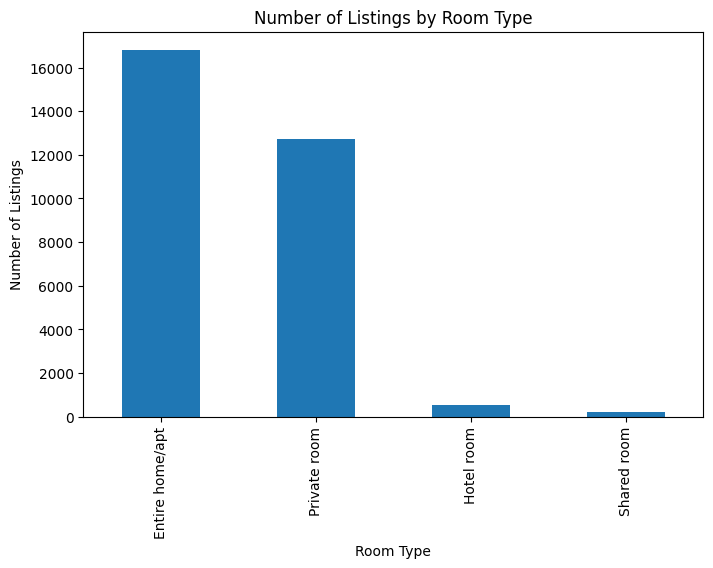

In [8]:
# Q1. Which room type has the most listings?

room_type=listings["room_type"].value_counts()

room_type

plt.figure(figsize=(8,5))
room_type.plot(kind="bar")
plt.title("Number of Listings by Room Type")
plt.xlabel("Room Type")
plt.ylabel("Number of Listings")

### Insight

Entire Home/Apartment is the dominant room type, indicating that most Airbnb hosts rent out entire properties rather than shared accommodations.

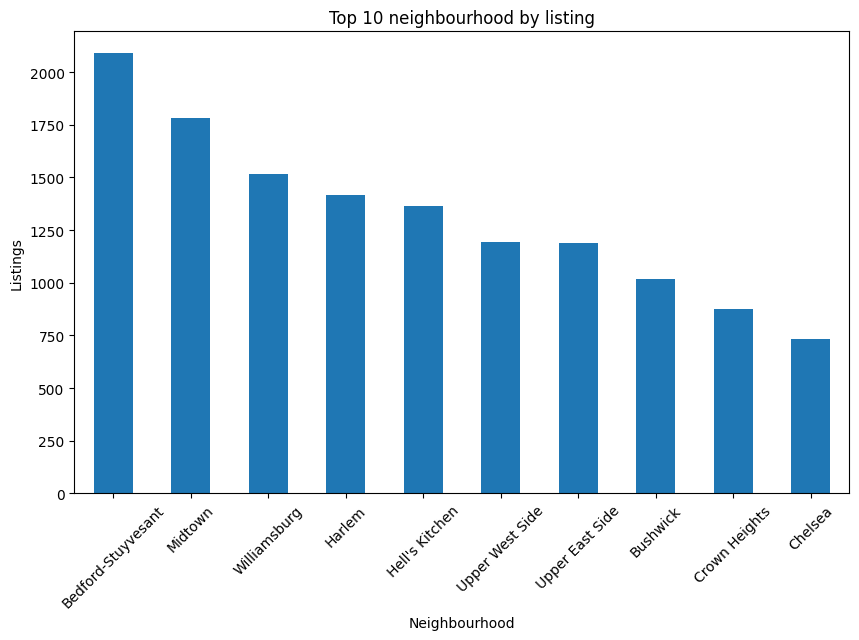

In [11]:
# Q2. Which neighbourhood has the highest number of listings

[col for col in listings.columns if "neighbourhood" in col.lower()]

top_neighbourhood=(listings["neighbourhood_cleansed"]
                   .value_counts().head(10))

top_neighbourhood


# Visualize
plt.figure(figsize=(10,6))

top_neighbourhood.plot(kind="bar")
plt.title("Top 10 neighbourhood by listing")
plt.xlabel("Neighbourhood")
plt.ylabel("Listings")

plt.xticks(rotation=45)

plt.show()

In [15]:
# Q3 Which neighbourhood has the highest price?

average_price=(listings.groupby("neighbourhood_cleansed")["price"]
               .mean().sort_values(ascending=False).head(10)
               )
average_price



neighbourhood_cleansed
Country Club          1384.233333
Tribeca               1255.072917
Fort Wadsworth        1010.330000
Civic Center           978.835000
Riverdale              734.860000
Navy Yard              667.900000
Brooklyn Heights       605.546786
Financial District     573.186514
West Village           550.619563
Midtown                545.088575
Name: price, dtype: float64

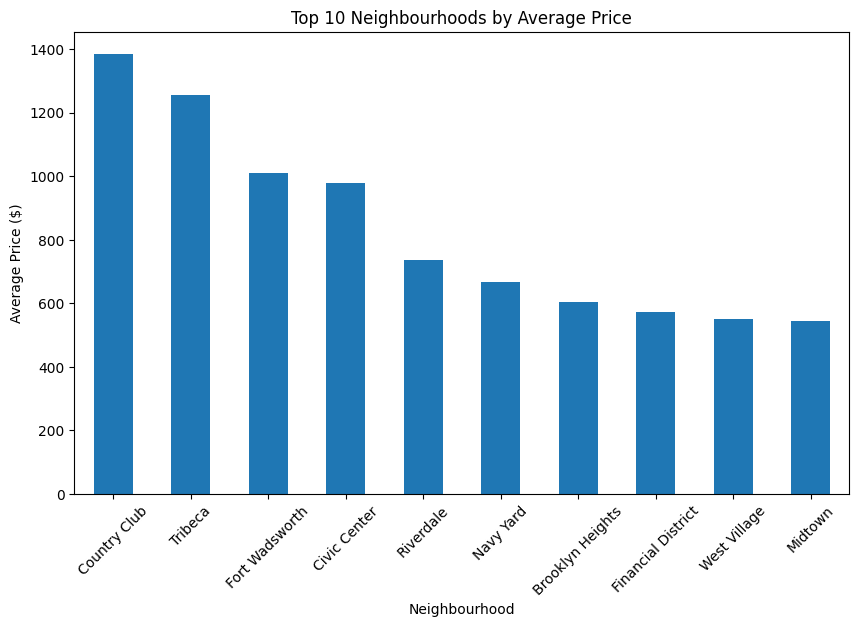

In [16]:
# Visulaization

plt.figure(figsize=(10,6))
average_price.plot(kind="bar")
plt.title("Top 10 Neighbourhoods by Average Price")
plt.xlabel("Neighbourhood")
plt.ylabel("Average Price ($)")

plt.xticks(rotation=45)

plt.show()

In [21]:
# Q4 Does the number of bedrooms influence the average listing price?

average_price_by_bedrooms = (
    listings
    .groupby("bedrooms")["price"]
    .mean()
    .sort_index()
)

average_price_by_bedrooms

bedrooms
0.0       79.178571
1.0      263.755604
2.0      365.339207
3.0      473.625231
4.0      778.226718
5.0      805.196984
6.0      980.052500
7.0     4389.027273
8.0     2231.937143
9.0     2398.445000
10.0    2200.000000
11.0            NaN
12.0    1723.000000
14.0    2246.100000
15.0    5841.000000
19.0    4291.000000
Name: price, dtype: float64

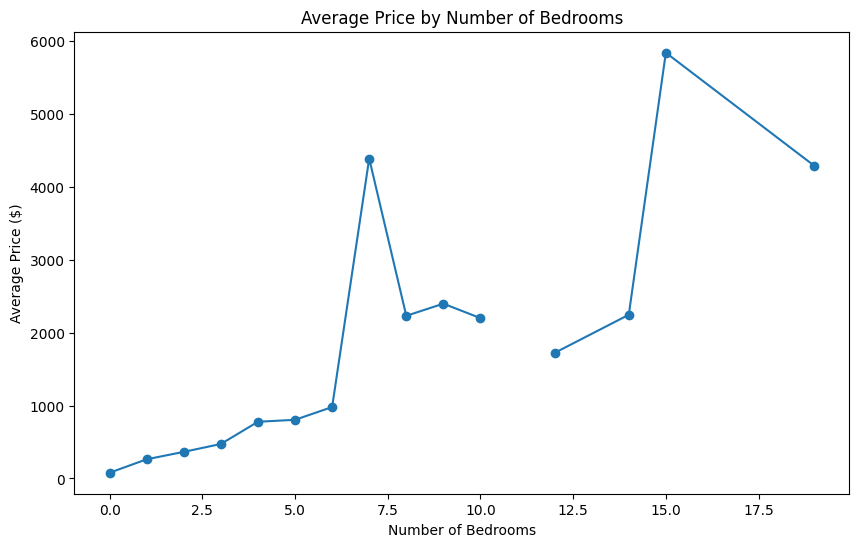

In [22]:
# Visulatization
plt.figure(figsize=(10,6))

average_price_by_bedrooms.plot( kind="line",marker="o")

plt.title("Average Price by Number of Bedrooms")
plt.xlabel("Number of Bedrooms")
plt.ylabel("Average Price ($)")

plt.show()

### Business Insight

- Average nightly prices generally increase as the number of bedrooms increases.
- Larger properties command premium prices because they accommodate more guests and cater to families or large groups.
- A sharp increase in prices for listings with many bedrooms suggests the presence of luxury or high-end properties.
- Property size is an important pricing factor, but it should be analyzed alongside location and amenities for a complete pricing strategy.

In [24]:
# Q5. Does accomodating more guest increase the price?

average_price_by_capacity = (
    listings
    .groupby("accommodates")["price"]
    .mean()
    .sort_index()
)

average_price_by_capacity

accommodates
1       97.879738
2      226.831339
3      271.015459
4      326.700492
5      402.619062
6      481.338595
7      504.483524
8      665.782618
9      743.086622
10     863.179268
11     737.150500
12    1017.901444
13     858.555000
14    2591.435600
15    1113.130000
16    1674.903590
Name: price, dtype: float64

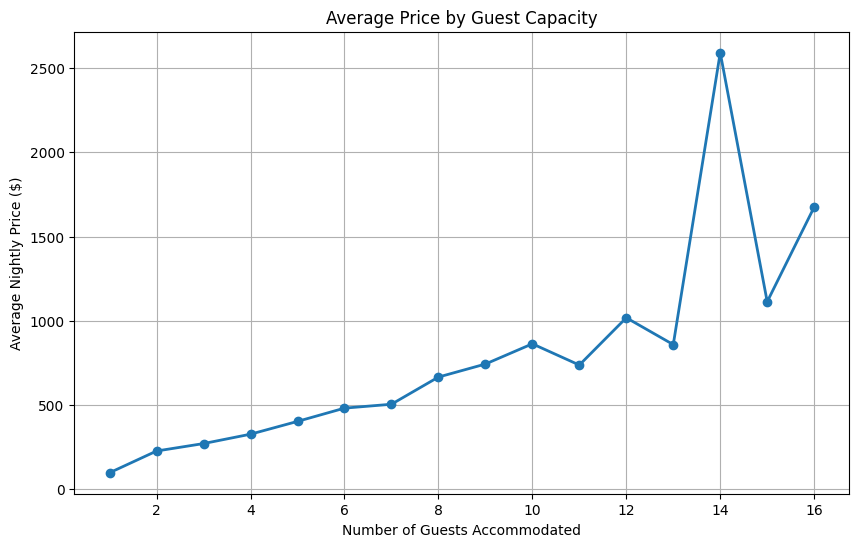

In [25]:
# Visualization

plt.figure(figsize=(10,6))

average_price_by_capacity.plot(
    kind="line",
    marker="o",
    linewidth=2
)

plt.title("Average Price by Guest Capacity")
plt.xlabel("Number of Guests Accommodated")
plt.ylabel("Average Nightly Price ($)")
plt.grid(True)

plt.show()

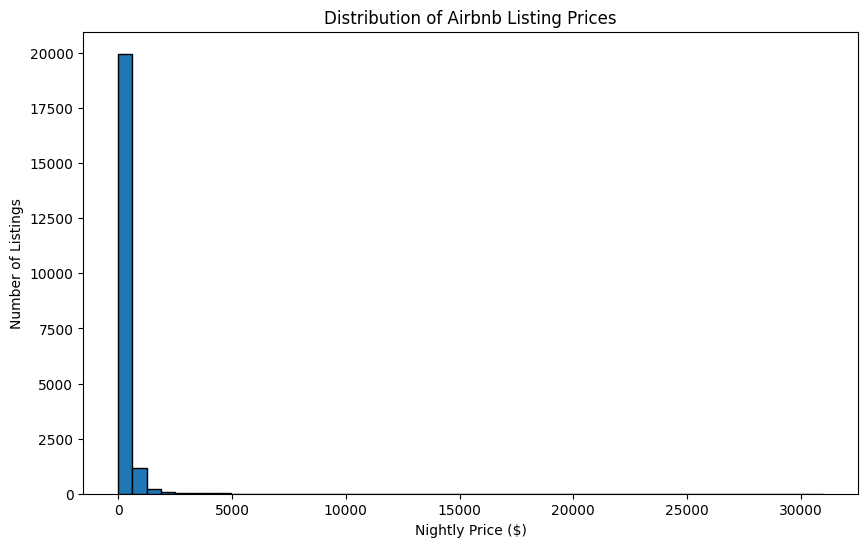

In [26]:
# Q6. How is AirBnb price distributed?

plt.figure(figsize=(10,6))

plt.hist(
    listings["price"],
    bins=50,
    edgecolor="black"
)

plt.title("Distribution of Airbnb Listing Prices")
plt.xlabel("Nightly Price ($)")
plt.ylabel("Number of Listings")

plt.show()

In [27]:
# Q7. Top 10 Airbnb listings

top_expensive=(
    listings[
        [
            "name",
            "neighbourhood_cleansed",
            "room_type",
            "bedrooms",
            "accommodates",
            "price"
        ]
    ].sort_values(by="price", ascending=False)
)

top_expensive

,name,neighbourhood_cleansed,room_type,bedrooms,accommodates,price
29997,"260 West Broadway, Unit 1/2C",Tribeca,Entire home/apt,7.0,14,30972.96
22075,Opulent Midtown Retreat with White-Gloved Service,Upper East Side,Hotel room,2.0,5,14864.00
22076,"Presidential Suite Park View King Bed, The Pierre",Upper East Side,Hotel room,2.0,5,14864.00
798,Sunny Luxury Bedroom Guest Bathroom,Murray Hill,Private room,NaN,2,12279.07
731,Enormous Chrysler-View Bedroom/Bath,Midtown,Private room,NaN,2,12078.47
...,...,...,...,...,...,...
29729,Elegant & Luxury,East Elmhurst,Entire home/apt,1.0,2,NaN
29745,Spectacular light-filled peaceful apartment,Harlem,Entire home/apt,1.0,1,NaN
29749,Spacious Modern Peaceful Spot,Harlem,Private room,1.0,1,NaN
29985,Large & Comfortable Room Near J Train Station,Woodhaven,Private room,1.0,2,NaN


In [29]:
# Q8. Which room recieves highest review rating?

room_rating=(
    listings.groupby("room_type")["review_scores_rating"].mean().sort_values(ascending=False)
)

room_rating

room_type
Entire home/apt    4.753724
Shared room        4.727333
Private room       4.712014
Hotel room         4.391377
Name: review_scores_rating, dtype: float64

In [31]:
# Q9. Which neighbourhood has the highest customer rating?

top_rating=(
    listings.groupby("neighbourhood_cleansed")["review_scores_rating"]
    .mean().sort_values(ascending=False).head(10)
)

top_rating

neighbourhood_cleansed
Neponsit                      5.000
Navy Yard                     5.000
Todt Hill                     5.000
West Farms                    5.000
Rossville                     5.000
Bay Terrace, Staten Island    5.000
Woodrow                       5.000
Dongan Hills                  5.000
Chelsea, Staten Island        5.000
Grymes Hill                   4.962
Name: review_scores_rating, dtype: float64

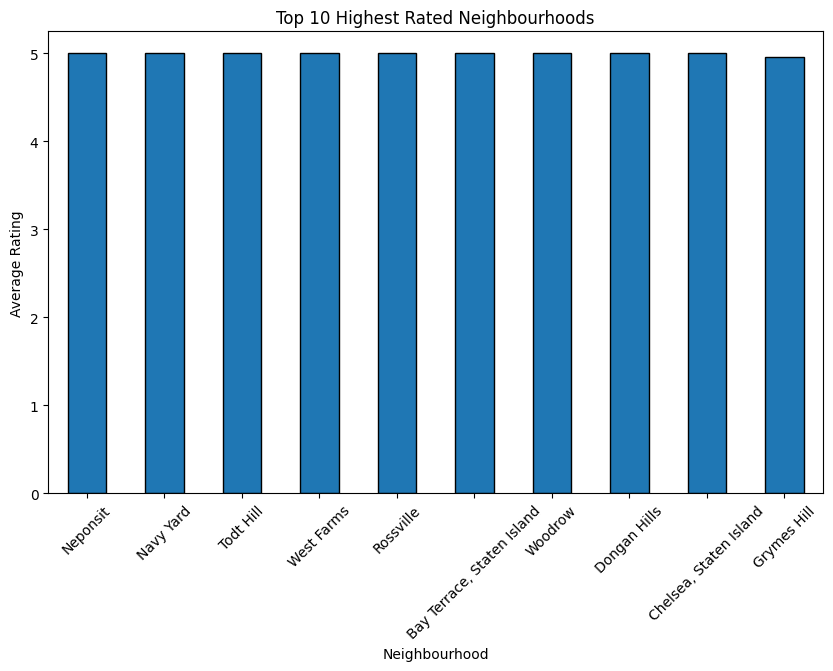

In [32]:
# Visualization

plt.figure(figsize=(10,6))

top_rating.plot(
    kind="bar",
    edgecolor="black"
)

plt.title("Top 10 Highest Rated Neighbourhoods")
plt.xlabel("Neighbourhood")
plt.ylabel("Average Rating")

plt.xticks(rotation=45)

plt.show()

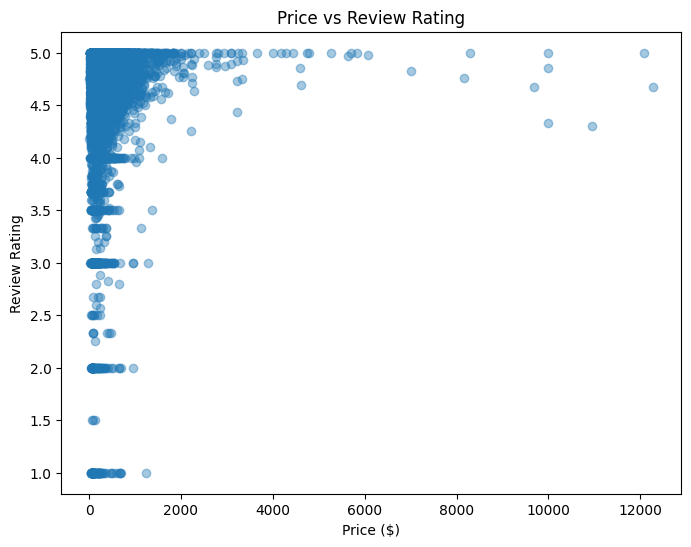

In [33]:
# Q10. Is there a relationship between price and customer rating?

plt.figure(figsize=(8,6))

plt.scatter(
    listings["price"],
    listings["review_scores_rating"],
    alpha=0.4
)

plt.title("Price vs Review Rating")
plt.xlabel("Price ($)")
plt.ylabel("Review Rating")

plt.show()

# Key Findings

- There is no strong relationship between listing price and customer review ratings.
- Both high-priced and budget-friendly listings receive high ratings, suggesting that guest satisfaction depends on factors beyond price, such as cleanliness, location, communication, and overall experience.
- This indicates that charging a higher price does not guarantee better customer reviews.